# Adaptive experiment design: an experimental cycle on an NV centre

## Running this notebook on your own machine

You need Python 3.11 or newer and `git`. From a terminal:

```bash
git clone https://github.com/pabigail/nuclear-spin-recovery.git
cd nuclear-spin-recovery

python3 -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate

pip install -e ".[dev]"            # the package, plus jupyterlab, jupytext, matplotlib

jupytext --to ipynb notebooks/adaptive_design.py
jupyter lab notebooks/adaptive_design.ipynb
```

Notebooks are stored in the repository as `.py` files (jupytext's percent
format) and converted to `.ipynb` locally; the `jupytext` line above does
that. Everything the notebook needs ships with the repository, including the
hyperfine table `nv-2.txt`, so nothing is downloaded while it runs. Start
Jupyter from the repository root or from `notebooks/` — the first code cell
finds the package either way. The whole notebook runs in well under a minute
on a laptop.

---

This notebook walks through the cycle an experimentalist would actually run:

```
  round 0:  sparse CPMG-4 measurement ──► quick fit ──► posterior
  round 1:  design (which N? which τ? how long?) ──► measure ──► refit
  round 2:  design ──► measure ──► refit
  ...
```

Each design round asks one question of the current posterior: **which CPMG
pulse number $N \in \{4, 8, 16, 32, 64\}$, at which delays $\tau$, averaged
for how long, would teach it the most for a fixed amount of lab time?** The
answer is scored by expected information gain (EIG) and printed as an
explicit measurement plan.

The pieces, all in `nuclear_spin_recovery.design`:

| piece | what it does |
|---|---|
| `ParticleSet` | the posterior as weighted, distinct baths — merged on couplings, not site index |
| `SequenceDuration` | what one repetition at each point costs in time: overhead $+\,2N\tau$ |
| `DecouplingScaling` | the decay constant at a pulse number not yet measured |
| `ExpectedInformationGain` | how much a candidate measurement would teach the posterior, in nats |
| `InformationDensity` | how to spend the time budget over the chosen candidate's delays |
| `ExperimentDesigner` | rank candidates at equal *wall-clock* time; propose a real `Experiment` |

The NV centre is simulated, so we know the true bath and can watch the
posterior close in on it. Everything the designer sees, though, is what a
lab would see: data, a posterior, and a cost model.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    ContinuousReflected,
    DecouplingScaling,
    DiscreteLatticeWalk,
    EnsembleRunner,
    ExpectedInformationGain,
    Experiment,
    ExperimentDesigner,
    ExperimentSet,
    GaussianL2,
    GreedyUtility,
    InformationDensity,
    NeighborIndex,
    ParallelTempering,
    ParameterBlock,
    ParticleSet,
    PredictiveVariance,
    Schedule,
    SequenceDuration,
    SiteTable,
    State,
    Step,
    StretchedExponential,
    Target,
    UniformThinning,
    information_density,
    simulate_dataset,
    spread_across_k,
)
from nuclear_spin_recovery.post import MATCH_TOL, matches, summarize

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
PULSES = (4, 8, 16, 32, 64)
COLORS = dict(zip(PULSES, plt.cm.viridis(np.linspace(0.05, 0.85, len(PULSES))),
                  strict=True))

## 1. The trade-off the designer has to weigh

The forward model is the closed form of Taminiau *et al.* for the sequence

$$\frac{\pi}{2} - \left(\tau - \pi - 2\tau - \pi - \tau\right)^{N/2} - \frac{\pi}{2},$$

so **$\tau$ is half the spacing between $\pi$ pulses** and one repetition
contains $2N\tau$ of free evolution. (That is checked against the model, not
assumed: a weakly coupled spin's first dip sits at
$\tau = \pi / (2\omega_L + A_\parallel)$.) Three things change with $N$:

1. **Selectivity.** A spin's dip deepens and narrows as $N$ grows; high $N$
   resolves couplings that low $N$ blurs together.
2. **Decay.** Decoherence is measured in *total* evolution time. Here the
   coherence time grows as $N^{\gamma}$ with $\gamma = 2/3$ — a scaling of the
   kind reported for NV centres under dynamical decoupling — so in $\tau$ the
   envelope's decay constant *shrinks*, as $\lambda_N \propto N^{\gamma - 1}$.
3. **Cost.** A repetition takes the per-shot overhead (initialisation and
   readout, 5 µs here) plus $2N\tau$: at $\tau = 2$ µs, 21 µs for CPMG-4 and
   261 µs for CPMG-64.

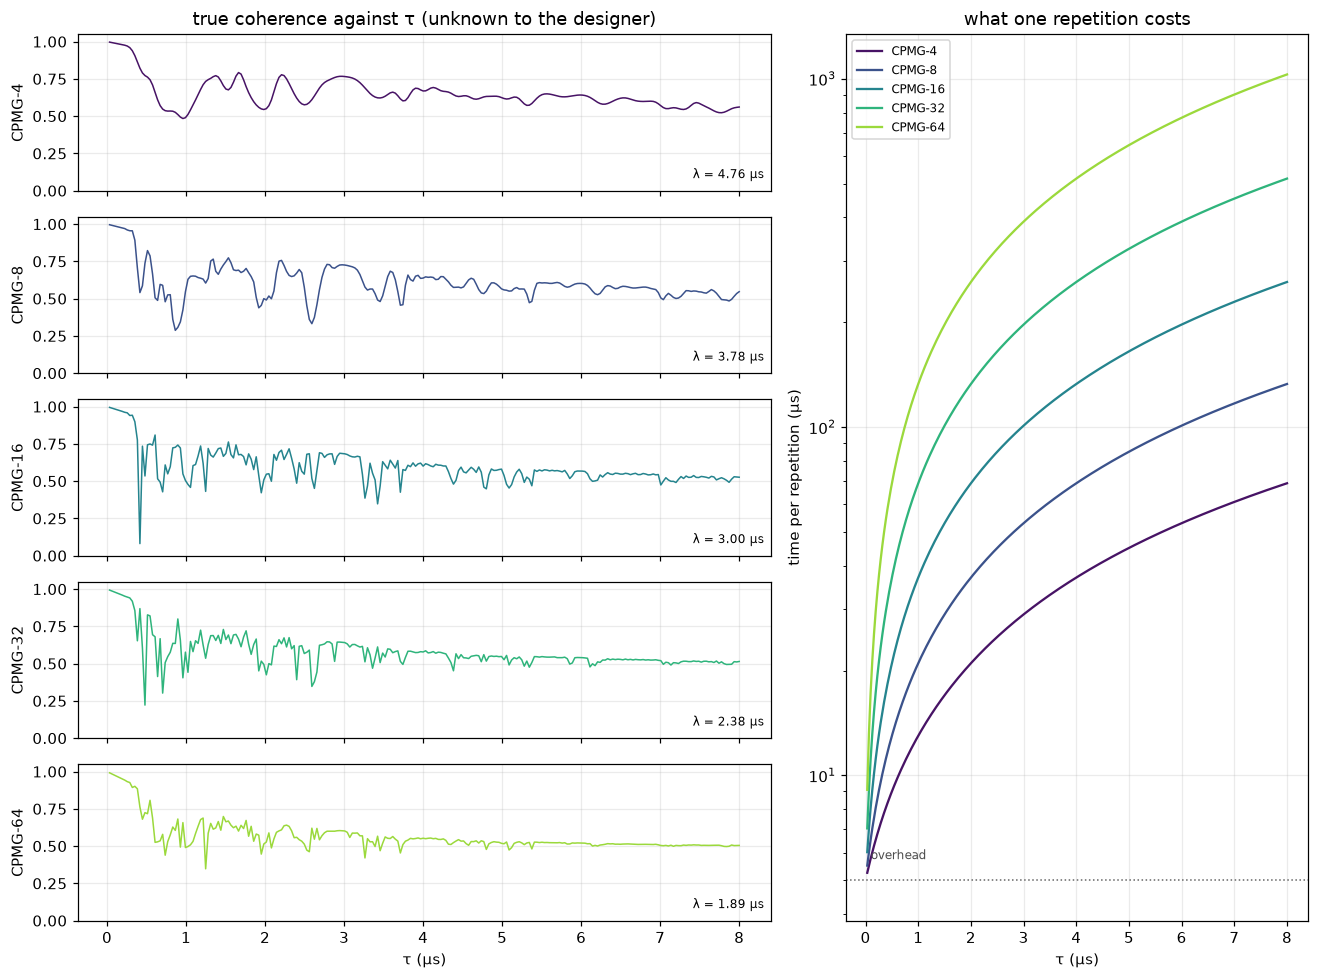

In [2]:
B_Z, K_MAX = 311.0, 32
GAMMA = 2 / 3                                     # coherence time ~ N^gamma
LAM_4 = 4.76e-3                                   # ms, true lambda at N = 4
LAM = {n: LAM_4 * (n / 4) ** (GAMMA - 1) for n in PULSES}
OVERHEAD = 5e-3                                   # ms per repetition
NOISE = 0.01                                      # per point, at unit weight
cost = SequenceDuration(OVERHEAD)
DENSE = np.linspace(0.0, 8e-3, 250, endpoint=False) + 8e-3 / 250   # ms

full = SiteTable.from_ivady_file(REPO / "nv-2.txt", strong_thresh=750.0,
                                 weak_thresh=5.0)
keep = np.hypot(full.a_par, full.a_perp) >= 100.0
table = SiteTable(distance=full.distance[keep], positions=full.positions[keep],
                  a_par=full.a_par[keep], a_perp=full.a_perp[keep],
                  isotope=full.isotope[keep], gyro=full.gyro[keep])
model = AnalyticCCE1(StretchedExponential())


def grid(n):
    return np.linspace(0.0, 8e-3, n, endpoint=False) + 8e-3 / n


def cpmg(tau, n_pulses, **kw):
    return Experiment(tau=np.asarray(tau, float), n_pulses=n_pulses, b_z=B_Z, **kw)


def make_state(sites, lam, sigma=0.02):
    """One configuration; ``lam`` has one decay constant per experiment."""
    lam = np.atleast_2d(np.asarray(lam, float))
    n_exp = lam.shape[1]
    return State.from_sites(np.sort(np.asarray(list(sites), int)),
                            n_sites=len(table), n_exp=n_exp, lam=lam,
                            n_stretch=np.ones((1, n_exp)),
                            sigma=np.full((1, n_exp), sigma), k_max=K_MAX)


true_sites = np.sort(np.random.default_rng(7).choice(len(table), 6,
                                                     replace=False))


def truth_for(expset):
    """The true bath, with the true decay constant for each experiment's N."""
    return make_state(true_sites, [[LAM[e.n_pulses] for e in expset.experiments]])


fig, axes = plt.subplots(len(PULSES), 2, figsize=(12, 9),
                         gridspec_kw={"width_ratios": [3, 2]})
for row, n in enumerate(PULSES):
    exp = ExperimentSet([cpmg(DENSE, n)])
    f = model.coherence(truth_for(exp), exp, table)[0]
    ax = axes[row, 0]
    ax.plot(DENSE * 1e3, f, color=COLORS[n], lw=1)
    ax.set(ylim=(0.0, 1.05), ylabel=f"CPMG-{n}")
    ax.text(0.99, 0.08, f"λ = {LAM[n] * 1e3:.2f} µs", transform=ax.transAxes,
            ha="right", fontsize=8)
    if row == 0:
        ax.set_title("true coherence against τ (unknown to the designer)")
    if row < len(PULSES) - 1:
        ax.set_xticklabels([])
axes[-1, 0].set_xlabel("τ (µs)")
gs = axes[0, 1].get_gridspec()
for ax in axes[:, 1]:
    ax.remove()
ax_cost = fig.add_subplot(gs[:, 1])
for n in PULSES:
    ax_cost.plot(DENSE * 1e3, cost(cpmg(DENSE, n)) * 1e3, color=COLORS[n],
                 label=f"CPMG-{n}")
ax_cost.axhline(OVERHEAD * 1e3, color="0.4", ls=":", lw=1)
ax_cost.text(0.1, OVERHEAD * 1e3 * 1.15, "overhead", fontsize=8, color="0.3")
ax_cost.set(yscale="log", xlabel="τ (µs)", ylabel="time per repetition (µs)",
            title="what one repetition costs")
ax_cost.legend(fontsize=8)
plt.tight_layout()

Left: the same bath through five sequences — broad, shallow dips at CPMG-4;
narrow, deep ones at CPMG-64, where the envelope has also eaten the signal
within a few microseconds. Right: the price of each repetition, one to two
orders of magnitude apart. Whatever a long sequence reveals has to be worth
its time.

## 2. Round 0: a sparse CPMG-4 measurement and a quick fit

The cycle starts cheaply: **16 delays of CPMG-4**, the shortest sequence on
offer. The fit is deliberately quick — four ensembles of 800 steps, pooled —
because in a real cycle the point of round 0 is to have *a* posterior to
design against, not a converged one. It samples the spins (birth–death moves
and a tempered site walk) and the decay constant of each experiment.

In [3]:
walk = DiscreteLatticeWalk(NeighborIndex(table.positions, radius=5.0))
schedule = Schedule([
    Step(RJMCMC(ParameterBlock("sites"), BirthDeathKernel(k_max=K_MAX)), 80),
    Step(ParallelTempering(Schedule([Step(RWMH(ParameterBlock("sites"), walk), 1)]),
                           n_replicas=6), 160),
    Step(RWMH(ParameterBlock("lam"), ContinuousReflected(3e-4, 2e-4, 2e-2)), 60),
])


def run(expset, init, root_seed, n_ensembles=4, n_steps=800, n_burn=300):
    runner = EnsembleRunner(schedule, n_ensembles=n_ensembles, n_steps=n_steps,
                            n_burn=n_burn, init=init, init_name="cycle")
    return runner.run(Target(expset, model, GaussianL2(), table),
                      root_seed=root_seed).pooled


true_pairs = [(table.a_par[s], table.a_perp[s]) for s in true_sites]


def is_truth(ps, i):
    """Whether particle ``i`` is the true bath, matched on couplings."""
    k = int(ps.k[i])
    if k != len(true_sites):
        return False
    s = ps.site_idx[i, :k]
    pairs = list(zip(table.a_par[s] + ps.dA_par[i, :k],
                     table.a_perp[s] + ps.dA_perp[i, :k], strict=True))
    return (all(matches(p, true_pairs, MATCH_TOL) for p in pairs)
            and all(matches(t, pairs, MATCH_TOL) for t in true_pairs))


def mass_on_truth(ps):
    return float(sum(ps.weight[i] for i in range(ps.n_particles)
                     if is_truth(ps, i)))


def describe(ps, pooled, data):
    s = summarize(pooled, data, table, model, reference=true_sites, burn=0,
                  stride=50, noise=NOISE, tol=MATCH_TOL)
    target = Target(data, model, GaussianL2(), table)
    truth_ll = float(target.log_prob(truth_for(data))[0])
    return {"best − truth log-lik": float(np.max(pooled.log_prob)) - truth_ll,
            "effective size": ps.effective_size,
            "entropy (nats)": float(-np.sum(ps.weight * np.log(ps.weight))),
            "mass on truth": mass_on_truth(ps),
            "mean R_i": float(np.mean(s.R_i)), "R_i": s.R_i}


round0 = cpmg(grid(16), 4)
data = simulate_dataset(truth_for(ExperimentSet([round0])),
                        ExperimentSet([round0]), table, model, sigma=NOISE,
                        rng=np.random.default_rng(9007))
cold = spread_across_k(lambda s: make_state(s, [[3e-3]]), (3, 9))
t0 = time.time()
pooled = run(data, cold, root_seed=7)
particles = ParticleSet.from_trace(pooled, table, stride=10)
history = [{"round": 0, "N": 4, "delays": 16,
            "time (µs/rep)": float(cost(round0).sum() * 1e3),
            **describe(particles, pooled, data)}]

print(f"round 0 fitted in {time.time() - t0:.0f} s")
print(f"   R_i per true spin : {np.round(history[0]['R_i'], 2)}")
print(f"   particles         : {particles.n_particles}, effective size "
      f"{particles.effective_size:.1f}")
print(f"   mass on truth     : {history[0]['mass on truth']:.2f}")
print(f"   sampled λ at N=4  : {particles.weight @ particles.lam[:, 0] * 1e3:.2f} µs "
      f"(true {LAM[4] * 1e3:.2f})")

round 0 fitted in 3 s
   R_i per true spin : [0.99 1.   0.08 0.28 0.57 0.08]
   particles         : 98, effective size 32.7
   mass on truth     : 0.00
   sampled λ at N=4  : 4.44 µs (true 4.76)


A sparse CPMG-4 measurement leaves the posterior wide: an effective size of
about 33 baths, three of the six true spins rarely present, and no weight at
all on the true bath — many configurations explain sixteen shallow-dipped
points equally well. That is the starting point for design.

## 3. Decay constants for pulse numbers not yet measured

To score a CPMG-32 candidate the designer needs each hypothesis's decay
constant *at* $N = 32$ — and after round 0 the posterior only knows it at
$N = 4$. Without help the designer refuses any pulse number it has not
measured. `DecouplingScaling(gamma)` supplies the missing assumption: the
coherence time grows as $N^\gamma$ in total time, so

$$\lambda_N = \lambda_{\text{ref}}\,(N / N_{\text{ref}})^{\gamma - 1},$$

scaled from the measured pulse number nearest in $\log N$. It only fills
gaps: once a pulse number has been measured, its own sampled $\lambda$ is used.

Here the designer is given the true $\gamma = 2/3$. On a real sample
$\gamma$ is an estimate, and the design should be checked for sensitivity to
it.

In [4]:
scaling = DecouplingScaling(GAMMA)
lam4 = particles.weight @ particles.lam[:, 0]
print("decay constant per pulse number, extrapolated from round 0's CPMG-4:")
for n in PULSES:
    print(f"   CPMG-{n:2d}: {scaling.scale(lam4, 4, n) * 1e3:5.2f} µs   "
          f"(true {LAM[n] * 1e3:.2f})")

decay constant per pulse number, extrapolated from round 0's CPMG-4:
   CPMG- 4:  4.44 µs   (true 4.76)
   CPMG- 8:  3.53 µs   (true 3.78)
   CPMG-16:  2.80 µs   (true 3.00)
   CPMG-32:  2.22 µs   (true 2.38)
   CPMG-64:  1.76 µs   (true 1.89)


## 4. Round 1: designing the next measurement

**Candidates** are every pulse number crossed with five windows of the dense
$\tau$ grid — 25 candidate experiments.

**The budget** for each round is the lab time round 0 took: the same number
of repetitions per point, times the sequence durations. Every candidate is
scored at that same wall-clock budget: the budget is split evenly over its
delays, and each delay's share buys share $/\,c_j$ repetitions, where $c_j$
is the duration of one repetition there. A CPMG-64 window gets far fewer
repetitions per delay than a CPMG-4 window, and pays for it in noise.

**The score** is expected information gain: simulate the measurement under
each hypothesis in turn, and ask how far the posterior would move. It is in
nats, bounded above by the posterior's entropy — no measurement can teach more
than there is left to learn.

CPMG- 4: best window 0.0–1.6 µs, EIG 3.02 nats
CPMG- 8: best window 0.0–1.6 µs, EIG 3.76 nats
CPMG-16: best window 0.0–1.6 µs, EIG 4.04 nats
CPMG-32: best window 0.0–1.6 µs, EIG 3.81 nats
CPMG-64: best window 0.0–1.6 µs, EIG 2.91 nats


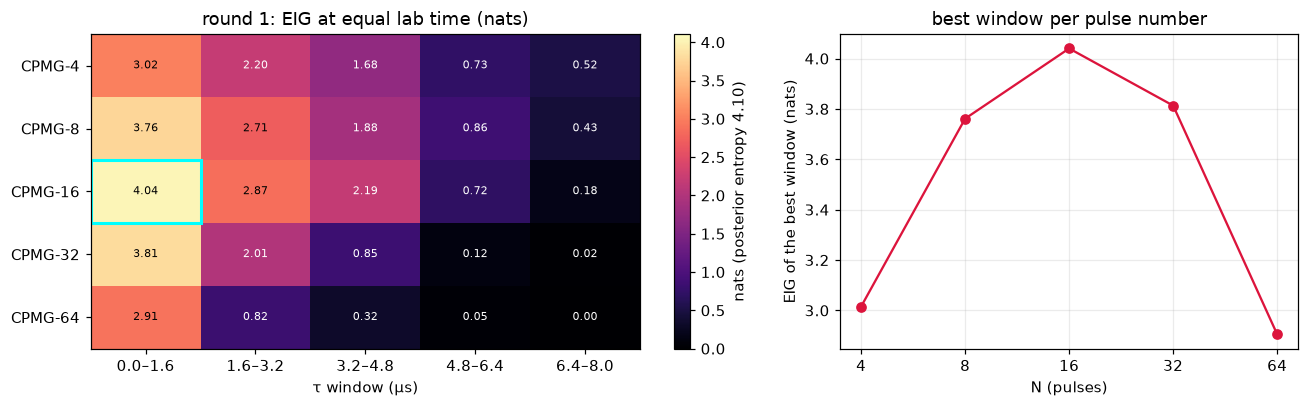

In [5]:
BUDGET = float(cost(round0).sum())                # round 0's lab time, ms
windows = np.array_split(DENSE, 5)
window_labels = [f"{w[0]*1e3:.1f}–{w[-1]*1e3:.1f}" for w in windows]
candidates = [cpmg(w, n) for n in PULSES for w in windows]


def designer_for(measured):
    return ExperimentDesigner(ExpectedInformationGain(n_draws=256),
                              InformationDensity(), model, table, measured,
                              cost=cost, envelope=scaling)


def eig_table(ps, measured, seed):
    scores = designer_for(measured).rank(ps, candidates, budget=BUDGET,
                                         rng=np.random.default_rng(seed))
    return scores.reshape(len(PULSES), len(windows))


def heatmap(ax, eig, entropy, title):
    im = ax.imshow(eig, cmap="magma", aspect="auto", vmin=0, vmax=entropy)
    for (r, c), v in np.ndenumerate(eig):
        ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="w" if v < 0.6 * entropy else "k")
    best = np.unravel_index(np.argmax(eig), eig.shape)
    ax.add_patch(plt.Rectangle((best[1] - 0.5, best[0] - 0.5), 1, 1, fill=False,
                               ec="cyan", lw=2))
    ax.set(xticks=range(len(windows)), xticklabels=window_labels,
           yticks=range(len(PULSES)), yticklabels=[f"CPMG-{n}" for n in PULSES],
           xlabel="τ window (µs)", title=title)
    ax.grid(False)
    return im


eig1 = eig_table(particles, data, seed=1)
entropy1 = history[0]["entropy (nats)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8),
                               gridspec_kw={"width_ratios": [3, 2]})
im = heatmap(ax1, eig1, entropy1, "round 1: EIG at equal lab time (nats)")
fig.colorbar(im, ax=ax1, label=f"nats (posterior entropy {entropy1:.2f})")
ax2.plot(PULSES, eig1.max(axis=1), "o-", color="crimson")
ax2.set_xscale("log", base=2)
ax2.set_xticks(PULSES, labels=[str(n) for n in PULSES])
ax2.minorticks_off()
ax2.set(xlabel="N (pulses)", ylabel="EIG of the best window (nats)",
        title="best window per pulse number")
plt.tight_layout()

for r, n in enumerate(PULSES):
    print(f"CPMG-{n:2d}: best window {window_labels[int(np.argmax(eig1[r]))]} µs, "
          f"EIG {eig1[r].max():.2f} nats")

Two things are visible at once. Across $\tau$, the earliest delays carry the
most — the dips that discriminate between hypotheses sit there, before the
envelope decays. Across pulse numbers there is an **interior optimum**:
CPMG-4 is cheap but its dips are too shallow to separate the hypotheses;
CPMG-64 is sharp but each repetition is so expensive that the budget buys
almost nothing. The best value per unit of lab time sits in between.

Here is the same trade-off point by point: the information density at each
delay (where the hypotheses disagree, in units of the noise) divided by the
cost of one repetition there.

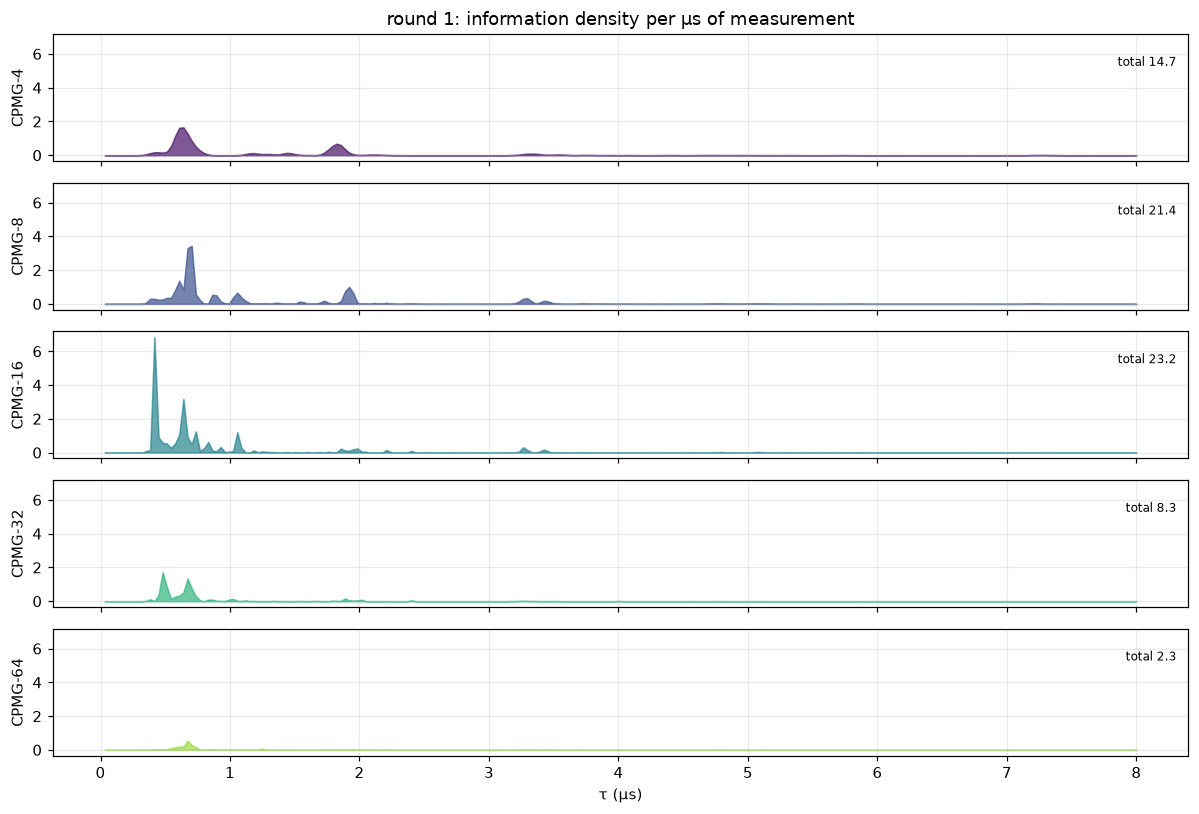

In [6]:
def predictions_at(ps, measured, n_pulses, tau):
    """Each particle's prediction for CPMG-``n_pulses`` at ``tau``, with the
    decay constant the designer would use."""
    d = designer_for(measured)
    lam, n_stretch, sig = d._envelope_for(ps, cpmg(tau, n_pulses))
    one = ParticleSet(ps.site_idx, ps.k, ps.weight, ps.dA_par, ps.dA_perp,
                      lam, n_stretch, sig, ps.n_sites, ps.k_max)
    return one.predictions(ExperimentSet([cpmg(tau, n_pulses)]), table, model)


sigma_design = float(particles.weight @ particles.sigma[:, 0])
fig, axes = plt.subplots(len(PULSES), 1, figsize=(11, 7.5), sharex=True,
                         sharey=True)
for ax, n in zip(axes, PULSES, strict=True):
    P = predictions_at(particles, data, n, DENSE)
    rate = (information_density(P, particles.weight, sigma_design)
            / (cost(cpmg(DENSE, n)) * 1e3))
    ax.fill_between(DENSE * 1e3, rate, color=COLORS[n], alpha=0.7)
    ax.set_ylabel(f"CPMG-{n}")
    ax.text(0.99, 0.75, f"total {rate.sum():,.1f}", transform=ax.transAxes,
            ha="right", fontsize=8)
axes[0].set_title("round 1: information density per µs of measurement")
axes[-1].set_xlabel("τ (µs)")
plt.tight_layout()

### The proposal, as a measurement plan

`propose` takes the best candidate, spends the budget over its delays with
`InformationDensity` — time in proportion to the square root of information
per unit time, small allocations pruned — and returns an ordinary
`Experiment`. Everything a lab needs is on it:

| field | meaning |
|---|---|
| `n_pulses` | the pulse sequence: CPMG with this many $\pi$ pulses |
| `b_z` | the static field along the NV axis, in G |
| `tau` | the delays, **in ms**: half the spacing between $\pi$ pulses |
| `weight` | repetitions, relative to the per-point count of round 0 |
| `sigma` | the noise the design assumed at unit weight |

**$\tau$ is half the pulse spacing**: the $\pi$ pulses are $2\tau$ apart,
with $\tau$ before the first and after the last. Use the same timing
convention as round 0's data. **Weights are relative repetitions**: 1 is as
many as each round-0 point received. Set `BASELINE_REPETITIONS` to that
count to get absolute numbers.

In [7]:
#: Repetitions averaged per point in ROUND 0. Set this to your own value.
BASELINE_REPETITIONS = 100_000


def measurement_plan(proposal, round_number, full=True):
    per_rep = cost(proposal)
    reps = np.maximum(1, np.round(proposal.weight * BASELINE_REPETITIONS)
                      ).astype(int)
    seconds = reps * per_rep / 1e3
    print(f"MEASUREMENT PLAN — round {round_number}")
    print(f"  sequence  : CPMG-{proposal.n_pulses}, i.e. π/2 – (τ – π – 2τ – π – τ)^"
          f"{proposal.n_pulses // 2} – π/2")
    print(f"  field     : B_z = {proposal.b_z:.0f} G along the NV axis")
    print(f"  delays    : {proposal.tau.size}, from {proposal.tau.min()*1e3:.3f} "
          f"to {proposal.tau.max()*1e3:.3f} µs")
    print(f"  total     : {reps.sum():,} repetitions, {seconds.sum():.1f} s of "
          f"acquisition (round 0 took "
          f"{BUDGET * BASELINE_REPETITIONS / 1e3:.1f} s)")
    if full:
        print(f"\n  {'#':>3}  {'τ (µs)':>7}  {'π spacing 2τ':>12}  {'per rep.':>9}  "
              f"{'weight':>7}  {'repetitions':>11}  {'time':>7}")
        for j, (t, c, w, r, s) in enumerate(zip(
                proposal.tau, per_rep, proposal.weight, reps, seconds,
                strict=True), 1):
            print(f"  {j:3d}  {t*1e3:7.3f}  {2*t*1e3:9.3f} µs  {c*1e3:6.1f} µs  "
                  f"{w:7.3f}  {r:11,d}  {s:5.2f} s")
    else:
        print("  τ (µs)    :", " ".join(f"{t*1e3:.3f}" for t in proposal.tau))
        print("  weights   :", " ".join(f"{w:.2f}" for w in proposal.weight))
    # What is actually measured has whole-number repetition counts.
    return cpmg(proposal.tau, proposal.n_pulses, sigma=proposal.sigma,
                weight=reps / BASELINE_REPETITIONS)


proposal1 = designer_for(data).propose(particles, candidates, budget=BUDGET,
                                       rng=np.random.default_rng(1),
                                       exclude=data)
plan1 = measurement_plan(proposal1, 1)

# To hand a plan to an instrument:
# np.savetxt("round1_plan.csv",
#            np.column_stack([plan1.tau, plan1.weight,
#                             np.round(plan1.weight * BASELINE_REPETITIONS)]),
#            delimiter=",", header="tau_ms,weight,repetitions", comments="")

MEASUREMENT PLAN — round 1
  sequence  : CPMG-16, i.e. π/2 – (τ – π – 2τ – π – τ)^8 – π/2
  field     : B_z = 311 G along the NV axis
  delays    : 33, from 0.352 to 1.600 µs
  total     : 2,421,807 repetitions, 62.4 s of acquisition (round 0 took 62.4 s)

    #   τ (µs)  π spacing 2τ   per rep.   weight  repetitions     time
    1    0.352      0.704 µs    16.3 µs    0.571       57,065   0.93 s
    2    0.384      0.768 µs    17.3 µs    0.731       73,081   1.26 s
    3    0.416      0.832 µs    18.3 µs    4.558      455,847   8.35 s
    4    0.448      0.896 µs    19.3 µs    1.581      158,115   3.06 s
    5    0.480      0.960 µs    20.4 µs    1.187      118,734   2.42 s
    6    0.512      1.024 µs    21.4 µs    1.092      109,248   2.34 s
    7    0.544      1.088 µs    22.4 µs    0.756       75,611   1.69 s
    8    0.576      1.152 µs    23.4 µs    0.994       99,351   2.33 s
    9    0.608      1.216 µs    24.5 µs    1.346      134,600   3.29 s
   10    0.640      1.280 µs    2

## 5. Measure, update, and design again

Each round now repeats the same three steps:

1. **Measure** the plan. Here that is simulated at the true bath, with noise
   $\sigma/\sqrt{w_j}$ at each delay.
2. **Update**: refit on everything measured so far. Chains **start from the
   previous posterior** — each at a bath drawn from its particles — rather
   than from scratch. In a sequential cycle the posterior should be carried
   forward; from cold starts, sharp data from a long sequence can leave chains
   stuck far below the truth for thousands of steps. A newly measured pulse
   number starts from the scaled decay constant and is then sampled.
3. **Design** the next round against the new posterior.

**Refits are longer than round 0's quick fit — eight ensembles of 1,200
steps — and that is measured, not cautious.** With round 0's four ensembles
of 800 steps, the refit failed to reach the true bath's likelihood on two of
three seeds tried: the best chain sat at −22 against the truth's −7, stuck,
and everything designed after it separated wrong hypotheses. At 8 × 1,200 the
best chain reached the truth's likelihood in every round on every seed. A
quick posterior is fine for deciding round 1; it is not fine to build a
cycle on.

The table in §6 therefore reports, every round, the best log-likelihood the
chains found minus the true bath's. A lab cannot compute that column — it
needs the truth — but here it is the check that a posterior is worth
designing against: near zero or above, the sampler found a fit as good as
the truth; far below, it is stuck.

In [8]:
def warm_start(ps, measured, combined):
    """Start each chain at a particle, with a decay constant per experiment:
    the particle's own where that experiment was already measured, scaled from
    the nearest measured pulse number where it is new."""
    known = len(measured.experiments)
    measured_n = [e.n_pulses for e in measured.experiments]

    def init(rng, index):
        i = rng.choice(ps.n_particles, p=ps.weight)
        k = int(ps.k[i])
        lam = []
        for j, e in enumerate(combined.experiments):
            if j < known:
                lam.append(ps.lam[i, j])
            else:
                ref = min(range(known), key=lambda r: abs(np.log(
                    measured_n[r] / e.n_pulses)))
                lam.append(float(scaling.scale(ps.lam[i, ref], measured_n[ref],
                                               e.n_pulses)))
        state = make_state(ps.site_idx[i, :k], [lam])
        state.dA_par[0, :k] = ps.dA_par[i, :k]
        state.dA_perp[0, :k] = ps.dA_perp[i, :k]
        return state
    return init


def measure_and_update(plan, measured, ps, round_number):
    followup = simulate_dataset(truth_for(ExperimentSet([plan])),
                                ExperimentSet([plan]), table, model,
                                sigma=NOISE,
                                rng=np.random.default_rng(5000 + round_number))
    combined = ExperimentSet(measured.experiments + followup.experiments)
    refit = run(combined, warm_start(ps, measured, combined),
                root_seed=100 + round_number, n_ensembles=8, n_steps=1200,
                n_burn=400)
    new_ps = ParticleSet.from_trace(refit, table, stride=10)
    history.append({"round": round_number, "N": plan.n_pulses,
                    "delays": plan.tau.size,
                    "time (µs/rep)": float(np.sum(plan.weight * cost(plan)) * 1e3),
                    **describe(new_ps, refit, combined)})
    return combined, new_ps


ROUNDS = 3
round0_particles, round0_data = particles, data
plans, eigs = {1: plan1}, {1: eig1}
t0 = time.time()
data, particles = measure_and_update(plan1, data, particles, 1)
for r in range(2, ROUNDS + 1):
    eigs[r] = eig_table(particles, data, seed=r)
    proposal = designer_for(data).propose(particles, candidates, budget=BUDGET,
                                          rng=np.random.default_rng(r),
                                          exclude=data)
    print()
    plans[r] = measurement_plan(proposal, r, full=False)
    data, particles = measure_and_update(plans[r], data, particles, r)
print(f"\n{ROUNDS} rounds of measure-and-update in {time.time() - t0:.0f} s")


MEASUREMENT PLAN — round 2
  sequence  : CPMG-32, i.e. π/2 – (τ – π – 2τ – π – τ)^16 – π/2
  field     : B_z = 311 G along the NV axis
  delays    : 27, from 0.320 to 1.536 µs
  total     : 1,484,135 repetitions, 62.4 s of acquisition (round 0 took 62.4 s)
  τ (µs)    : 0.320 0.352 0.384 0.416 0.448 0.480 0.512 0.544 0.576 0.608 0.640 0.672 0.704 0.736 0.768 0.800 0.832 0.864 0.896 1.120 1.152 1.248 1.280 1.376 1.408 1.504 1.536
  weights   : 0.26 0.94 1.09 0.39 0.65 2.72 2.17 0.26 0.66 0.61 0.86 1.14 0.74 0.82 0.20 0.09 0.30 0.16 0.19 0.10 0.06 0.06 0.10 0.07 0.09 0.05 0.06



MEASUREMENT PLAN — round 3
  sequence  : CPMG-64, i.e. π/2 – (τ – π – 2τ – π – τ)^32 – π/2
  field     : B_z = 311 G along the NV axis
  delays    : 31, from 0.320 to 1.568 µs
  total     : 733,146 repetitions, 62.4 s of acquisition (round 0 took 62.4 s)
  τ (µs)    : 0.320 0.352 0.384 0.416 0.448 0.480 0.512 0.544 0.576 0.640 0.672 0.704 0.736 0.768 0.800 0.832 0.864 0.896 0.960 1.120 1.152 1.216 1.248 1.280 1.312 1.344 1.376 1.408 1.472 1.504 1.568
  weights   : 0.47 0.22 0.24 1.12 0.62 0.70 0.25 0.11 0.16 0.23 1.00 0.22 0.76 0.11 0.09 0.06 0.05 0.13 0.09 0.06 0.04 0.03 0.11 0.09 0.03 0.03 0.04 0.11 0.05 0.05 0.04



3 rounds of measure-and-update in 46 s


## 6. What the cycle did

Each row is the posterior *after* that round's measurement.

In [9]:
cols = ("round", "N", "delays", "best − truth log-lik", "effective size",
        "entropy (nats)", "mass on truth", "mean R_i")
print("  ".join(f"{c:>20}" for c in cols))
for h in history:
    print("  ".join(f"{h[c]:>20.2f}" if isinstance(h[c], float) else f"{h[c]:>20}"
                    for c in cols))

               round                     N                delays  best − truth log-lik        effective size        entropy (nats)         mass on truth              mean R_i
                   0                     4                    16                 -0.48                 32.68                  4.10                  0.00                  0.50
                   1                    16                    33                  0.04                  6.35                  2.23                  0.30                  0.86
                   2                    32                    27                  0.57                  3.67                  1.74                  0.46                  0.90
                   3                    64                    31                  0.64                  4.41                  1.85                  0.42                  0.92


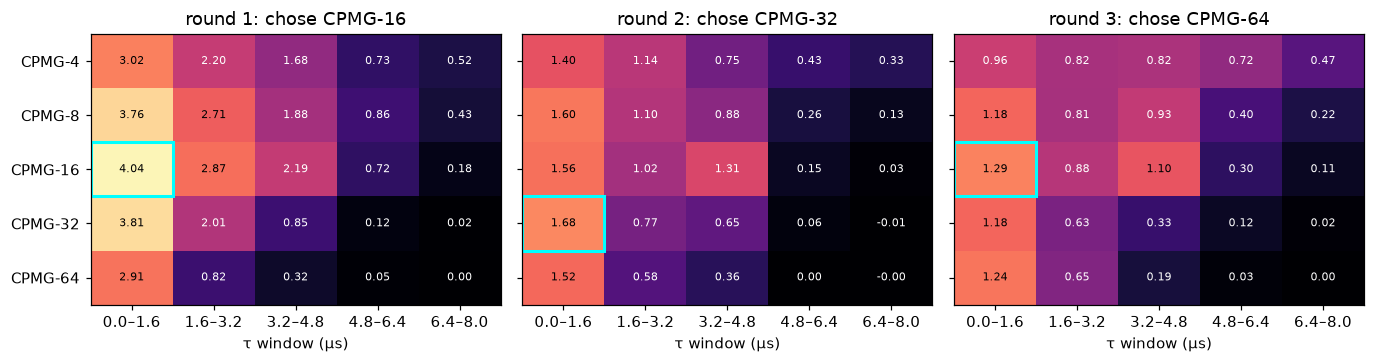

In [10]:
fig, axes = plt.subplots(1, ROUNDS, figsize=(4.2 * ROUNDS, 3.4))
for ax, r in zip(axes, range(1, ROUNDS + 1), strict=True):
    heatmap(ax, eigs[r], history[r - 1]["entropy (nats)"],
            f"round {r}: chose CPMG-{plans[r].n_pulses}")
    if r > 1:
        ax.set_yticklabels([])
plt.tight_layout()

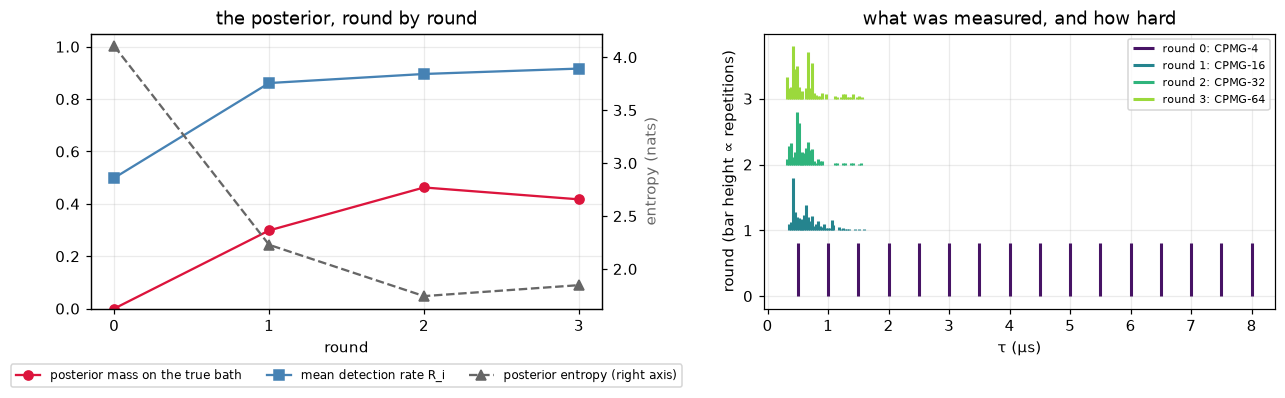

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
rounds = [h["round"] for h in history]
ax1.plot(rounds, [h["mass on truth"] for h in history], "o-", color="crimson",
         label="posterior mass on the true bath")
ax1.plot(rounds, [h["mean R_i"] for h in history], "s-", color="steelblue",
         label="mean detection rate R_i")
ax1.set(xlabel="round", ylim=(0, 1.05), xticks=rounds,
        title="the posterior, round by round")
ax1b = ax1.twinx()
ax1b.plot(rounds, [h["entropy (nats)"] for h in history], "^--", color="0.4",
          label="posterior entropy (right axis)")
ax1b.set_ylabel("entropy (nats)", color="0.4")
ax1b.grid(False)
handles = ax1.get_legend_handles_labels()
handles_b = ax1b.get_legend_handles_labels()
ax1.legend(handles[0] + handles_b[0], handles[1] + handles_b[1], fontsize=8,
           loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)

ax2.vlines(round0.tau * 1e3, 0, 0.8, color=COLORS[4], lw=2,
           label="round 0: CPMG-4")
for r, plan in plans.items():
    ax2.vlines(plan.tau * 1e3, r, r + 0.8 * plan.weight / plan.weight.max(),
               color=COLORS[plan.n_pulses], lw=2,
               label=f"round {r}: CPMG-{plan.n_pulses}")
ax2.set(xlabel="τ (µs)", ylabel="round (bar height ∝ repetitions)",
        yticks=range(ROUNDS + 1), title="what was measured, and how hard")
ax2.legend(fontsize=7, loc="upper right")
plt.tight_layout()

Read the three heatmaps left to right; each is scaled to that round's
posterior entropy, the most there was left to learn. The first column of the
table is the sanity check: in every round the chains found a fit at least as
good as the true bath's, so each design was made against a posterior the
sampler had actually explored.

- **Round 1** chooses CPMG-16 at the earliest delays — the interior optimum
  of the trade-off in §1. The effective size falls from 33 to about 6, the
  true bath goes from no weight to 0.30, and mean $R_i$ from 0.50 to 0.86.
- **Round 2**: what remains are hypotheses CPMG-16 could not tell apart, and
  the best value moves to CPMG-32, whose sharper dips can. The true bath
  rises to 0.46 of the weight.
- **Round 3** chooses CPMG-64, and the posterior barely moves — slightly
  *less* sure, if anything (effective size 3.7 to 4.4, weight on the truth
  0.46 to 0.42), while detection edges up to 0.92. EIG is the gain
  *expected* over the outcomes the posterior thinks likely; any one
  measurement can realise less. The hypotheses still standing differ only
  subtly, and another 62 s of any sequence separates them only partly.

Here the choices climb 16 → 32 → 64, but that is not a rule. On other refit
seeds tried, the same cycle went 16 → 32 → 32 and 16 → 64 → 32: each round
asks which sequence best separates the hypotheses still standing, at the
price of a repetition, and the answer depends on which those are. Round 1,
made against the same round-0 posterior every time, chose CPMG-16 on every
seed.

## 7. What this does and does not show

- **One bath, one seed, no control.** The cycle shows the posterior
  changing round by round, but not that design beat the alternative: a
  fixed CPMG-16 grid with the same lab time might have done as well. That
  comparison — adaptive against uniform at equal time, with an anti-design
  control — is the T9 rung, calibrated over many baths by
  `scripts/calibrate_t9.py`.
- **Round 0's fit is quick; the refits cannot be.** Four ensembles of 800
  steps were enough to choose round 1, but as refits they got stuck on two of
  three seeds, and a cycle built on a stuck posterior separates the wrong
  hypotheses efficiently. A real cycle should check its fits before designing
  against them — with ensemble agreement, since a lab has no true bath to
  compare to.
- **$\gamma$ is an assumption.** Until a pulse number is measured, its decay
  constant comes from `DecouplingScaling`; here the designer was given the
  true $\gamma$. On a real sample, estimate it and check how much the chosen
  pulse number moves with it.
- **The design is greedy for one round**: it maximises what the next
  measurement tells the current posterior, and nothing about the round after.
- **The cost model is yours to set.** `SequenceDuration(overhead)` has no
  default overhead on purpose: it decides how expensive a long sequence is
  relative to a short one.

## Appendix: inside the designer

Both demonstrations use the round-0 posterior and round 1's decision.

### Spending a budget over delays

Once a candidate is chosen, a selector decides which delays to measure and
for how long. With a cost model every selector spends **time**: the weights
are relative repetitions, and $\sum_j w_j c_j$ equals the budget.

| selector | rule |
|---|---|
| `UniformThinning(n)` | evenly spaced, equal time per delay — the control |
| `InformationDensity()` | time $\propto$ (density / cost)$^{1/2}$, small allocations pruned |
| `GreedyUtility(utility, n)` | add the delay that most improves a utility, equal time each |

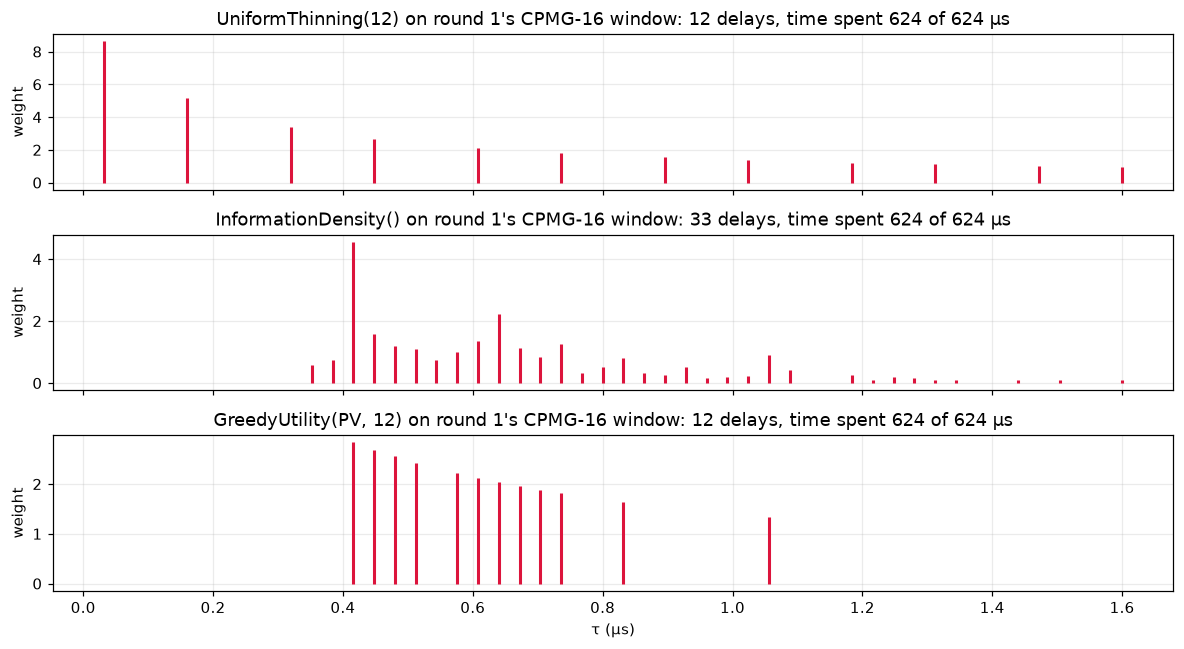

In [12]:
best1 = int(np.argmax(eig1))
win_cand = candidates[best1]
Pw = predictions_at(round0_particles, round0_data, win_cand.n_pulses,
                    win_cand.tau)
cw = cost(win_cand)
selectors = {"UniformThinning(12)": UniformThinning(12),
             "InformationDensity()": InformationDensity(),
             "GreedyUtility(PV, 12)": GreedyUtility(PredictiveVariance(), 12)}
fig, axes = plt.subplots(len(selectors), 1, figsize=(11, 6), sharex=True)
for ax, (name, sel) in zip(axes, selectors.items(), strict=True):
    idx, w = sel.select(Pw, round0_particles.weight, sigma_design, BUDGET,
                        np.random.default_rng(0), cost=cw)
    ax.vlines(win_cand.tau[idx] * 1e3, 0, w, color="crimson", lw=2)
    ax.set(ylabel="weight", title=f"{name} on round 1's CPMG-{win_cand.n_pulses} "
           f"window: {len(idx)} delays, time spent "
           f"{np.sum(w * cw[idx]) * 1e3:,.0f} of {BUDGET * 1e3:,.0f} µs")
axes[-1].set_xlabel("τ (µs)")
plt.tight_layout()

`UniformThinning` gives equal *time* to each delay, so later delays — longer
repetitions — get fewer repetitions. `InformationDensity` is the rule of the
original `adaptive_exp.py`. `GreedyUtility` with predictive variance is
exactly "the top delays by information per unit time".

### Common random numbers

EIG is a Monte Carlo estimate, and only its *ranking* matters, so
`score_many` scores every candidate with the same sampled hypotheses and the
same noise draws. Two candidates a little apart keep their order from seed to
seed; with independent draws they swap.

In [13]:
flat = eig1.ravel()
order = np.argsort(-flat)
second = order[np.argmax(flat[order[0]] - flat[order] > 0.08)]
pair = [candidates[order[0]], candidates[second]]
flips = {}
for shared in (True, False):
    d = ExperimentDesigner(ExpectedInformationGain(n_draws=64,
                                                   common_random=shared),
                           InformationDensity(), model, table, round0_data,
                           cost=cost, envelope=scaling)
    diffs = [np.subtract(*d.rank(round0_particles, pair, budget=BUDGET,
                                 rng=np.random.default_rng(s)))
             for s in range(40)]
    flips[shared] = int(np.sum(np.asarray(diffs) < 0))
print(f"CPMG-{pair[0].n_pulses} against CPMG-{pair[1].n_pulses} "
      f"({flat[order[0]] - flat[second]:.2f} nats apart), 64 draws, 40 seeds:")
print(f"   shared draws      : ranking flipped on {flips[True]:2d}")
print(f"   independent draws : ranking flipped on {flips[False]:2d}")

CPMG-16 against CPMG-32 (0.23 nats apart), 64 draws, 40 seeds:
   shared draws      : ranking flipped on  1
   independent draws : ranking flipped on  8
